## Preparação do Ambiente

### Instalação de Pacotes

In [1]:
! pip install --upgrade -q pandas numpy scikit-learn imbalanced-learn matplotlib catboost optuna plotly nbformat kaleido

### Importação de Bibliotecas

In [2]:
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score

from imblearn.over_sampling import SMOTENC
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

from catboost import CatBoostClassifier

import optuna
import pickle
import optuna.visualization as vis

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

### Constantes

#### Local

In [16]:
import sys
from pathlib import Path

# adiciona a pasta src ao sys.path
SRC_DIR = Path().resolve().parent  # .../src
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from utils.constants import *

DATASET_PATH = "../../data/3_gold/dataset-processed-gb-old.csv"

#### Kaggle

In [15]:
CATEGORICAL_COLUMNS = {
    "gestante_paciente", "raca_cor_paciente", "sigla_uf_residencia"
}

RANDOM_STATE = 42
TEST_RATIO = 0.15
N_FOLDS = 5
N_CLASSES = 3

TARGET_NAMES = ["low_risk", "alarm", "severe"]
TARGET_NAMES_COARSE = ["low_risk", "high_risk"]
TARGET_NAMES_FINE = ["alarm", "severe"] 


TARGET_LABEL_MAP = {name: idx for idx, name in enumerate(TARGET_NAMES)}
LABEL_TARGET_MAP = {idx: name for idx, name in enumerate(TARGET_NAMES)}

DATASET_PATH = "../input/sinan-sbcas/dataset-processed-gb.csv"

## Carregamento dos Dados

In [ ]:
df = pd.read_csv(DATASET_PATH)

categorical_features = list(CATEGORICAL_COLUMNS)

for col in categorical_features:
    df[col] = df[col].astype('category')

X = df.drop("class", axis=1)
y = df["class"]
y = y.map(TARGET_LABEL_MAP)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y
)

In [18]:
def get_coarse_fine_data(X, y):
    X_coarse = X.copy()
    y_coarse = y.copy()
    y_coarse = y_coarse.map(COARSE_LABEL_MAP)

    high_risk_mask = y.isin([1, 2])
    X_fine = X[high_risk_mask].copy()
    y_fine = y[high_risk_mask].copy()
    y_fine = y_fine.map(FINE_LABEL_MAP)

    return X_coarse, y_coarse, X_fine, y_fine

In [19]:
def predict_soft_cascade(model_coarse, model_fine, X, y):
    # Get Probabilities from Coarse
    probs_coarse = model_coarse.predict_proba(X)
    p_high_risk = probs_coarse[:, 1]
    
    # Get Probabilities from Fine
    probs_fine = model_fine.predict_proba(X) 
    p_severe_given_high = probs_fine[:, 1] # P(Severe | High)
        
    # P(Severe) = P(High) * P(Severe | High)
    p_severe_global = p_high_risk * p_severe_given_high
    
    # P(Alarm) = P(High) * (1 - P(Severe | High))
    p_alarm_global = p_high_risk * (1 - p_severe_given_high)
    
    # P(Low) = 1 - P(High)
    p_low_global = 1.0 - p_high_risk
    
    final_probs = np.vstack([p_low_global, p_alarm_global, p_severe_global]).T
    final_preds = np.argmax(final_probs, axis=1)

    return f1_score(y, final_preds, average='macro'), final_preds


def predict_hard_cascade(
    model_coarse, model_fine, X, y, 
    threshold_coarse=0.5, threshold_fine=0.5
):
    # Predict Coarse (0 = Low, 1 = High)
    probs_coarse = model_coarse.predict_proba(X)[:, 1]
    
    preds_coarse = (probs_coarse >= threshold_coarse).astype(int)
    final_preds = preds_coarse.copy()
    
    high_risk_indices = np.where(preds_coarse == 1)[0]
    
    if len(high_risk_indices) > 0:
        X_high_risk = X.iloc[high_risk_indices]
        
        # Predict Fine (0 = Alarm, 1 = Severe)
        probs_fine_local = model_fine.predict_proba(X_high_risk)[:, 1]
        preds_fine_local = (probs_fine_local >= threshold_fine).astype(int)
        
        # Map Fine predictions back to Global labels
        preds_fine_global = np.array([FINE_LABEL_MAP_REVERSE[p] for p in preds_fine_local])
        final_preds[high_risk_indices] = preds_fine_global

    return f1_score(y, final_preds, average='macro'), final_preds

## Treinamento com Validação Cruzada

In [20]:
def train_on_folds(params_coarse, params_fine, use_soft_cascade, threshold_coarse=None, threshold_fine=None):
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scores = []

    for train_idx, valid_idx in skf.split(X_train_full, y_train_full):
        X_train, y_train = X_train_full.iloc[train_idx], y_train_full.iloc[train_idx]
        X_valid, y_valid = X_train_full.iloc[valid_idx], y_train_full.iloc[valid_idx]

        clf_coarse = CatBoostClassifier(**params_coarse)
        clf_fine = CatBoostClassifier(**params_fine)

        X_coarse, y_coarse, X_fine, y_fine = get_coarse_fine_data(X_train, y_train)
        X_valid_coarse, y_valid_coarse, X_valid_fine, y_valid_fine = get_coarse_fine_data(X_valid, y_valid)

        try:
            clf_coarse.fit(X_coarse, y_coarse, eval_set=(X_valid_coarse, y_valid_coarse), use_best_model=True)
            clf_fine.fit(X_fine, y_fine, eval_set=(X_valid_fine, y_valid_fine), use_best_model=True)

            if use_soft_cascade:
                f1, _ = predict_soft_cascade(clf_coarse, clf_fine, X_valid, y_valid)
            else:
                f1, _ = predict_hard_cascade(
                    clf_coarse, clf_fine, X_valid, y_valid,
                    threshold_coarse, threshold_fine
                )
            
            scores.append(f1)
        except ValueError:
            return 0.0, 1.0

    return np.mean(scores), np.std(scores)


## Otimização de Hiperparâmetros

In [21]:
FIXED_PARAMS = {
    'iterations': 2000,
    'loss_function': 'MultiClass',
    'eval_metric': 'AUC',         
    'auto_class_weights': 'Balanced',
    'early_stopping_rounds': 5,
    'random_state': RANDOM_STATE,
    'cat_features': categorical_features,
    'allow_writing_files': False
}

### Definição da Função Objetivo

In [ ]:
def objective(trial: optuna.trial.Trial):
    params_coarse = {
        'learning_rate': trial.suggest_float('learning_rate_coarse', 1e-3, 1e-1, log=True),
        'depth': trial.suggest_int('depth_coarse', 5, 10, step=1),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel_coarse', 0.1, 1.0, step=0.1),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf_coarse', 1, 50),
        'bootstrap_type': trial.suggest_categorical('bootstrap_type_coarse', ['Bayesian', 'Bernoulli', 'MVS']),
        **FIXED_PARAMS
    }    
    params_fine = {
        'learning_rate': trial.suggest_float('learning_rate_fine', 1e-3, 1e-1, log=True),
        'depth': trial.suggest_int('depth_fine', 5, 10, step=1),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel_fine', 0.1, 1.0, step=0.1),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf_fine', 1, 50),
        'bootstrap_type': trial.suggest_categorical('bootstrap_type_fine', ['Bayesian', 'Bernoulli', 'MVS']),
        **FIXED_PARAMS
    }

    if params_coarse['bootstrap_type'] == 'Bayesian':
        params_coarse['bagging_temperature'] = trial.suggest_float('bagging_temperature_coarse', 0, 10)
    elif params_coarse['bootstrap_type'] == 'Bernoulli':
        params_coarse['subsample'] = trial.suggest_float('subsample_coarse', 0.1, 1.0, log=True)

    if params_fine['bootstrap_type'] == 'Bayesian':
        params_fine['bagging_temperature'] = trial.suggest_float('bagging_temperature_fine', 0, 10)
    elif params_fine['bootstrap_type'] == 'Bernoulli':
        params_fine['subsample'] = trial.suggest_float('subsample_fine', 0.1, 1.0, log=True)

    mode = trial.suggest_categorical("mode", choices=["soft", "hard"])

    threshold_coarse = None
    threshold_fine = None
    use_soft_cascade = (mode == "soft")
    
    if not use_soft_cascade:
        threshold_coarse = trial.suggest_float("threshold_coarse", low=0.3, high=0.5, step=0.05)
        threshold_fine = trial.suggest_float("threshold_fine", low=0.3, high=0.5, step=0.05)

    avg, _ = train_on_folds(params_coarse, params_fine, use_soft_cascade, threshold_coarse, threshold_fine)
    return avg

### Otimização com Optuna

In [ ]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, timeout=14400, show_progress_bar=True, n_jobs=-1)

best_trial = study.best_trial
print('Best F1:', best_trial.value)
print('Best Params:', best_trial.params)

# Best F1: 0.5152996274562298
# Best Params: {'learning_rate_coarse': 0.0337314168080377, 'depth_coarse': 10, 'colsample_bylevel_coarse': 0.8, 'min_data_in_leaf_coarse': 7, 'bootstrap_type_coarse': 'MVS', 'learning_rate_fine': 0.07404977644601698, 'depth_fine': 10, 'colsample_bylevel_fine': 0.9, 'min_data_in_leaf_fine': 37, 'bootstrap_type_fine': 'MVS', 'mode': 'soft'}

In [ ]:
output_dir = Path('results/optimization/catboost/multi')
output_dir.mkdir(parents=True, exist_ok=True)

with open(output_dir / 'optuna_study.pkl', 'wb') as fout:
    pickle.dump(study.sampler, fout)

### Visualizações

In [ ]:
display(vis.plot_param_importances(study))
display(vis.plot_optimization_history(study))

In [ ]:
vis.plot_param_importances(study).write_image(output_dir / 'opt_param_importances.png')
vis.plot_optimization_history(study).write_image(output_dir / 'opt_hist.png')

### Melhor Modelo

In [12]:
BEST_PARAMS = {
    'learning_rate': 0.03158826697434671, 
    'depth': 8, 'colsample_bylevel': 0.6, 
    'min_data_in_leaf': 19, 
    'bootstrap_type': 'Bayesian', 
    'bagging_temperature': 0.1985479799912282
}

In [14]:
final_params = {**BEST_PARAMS, **FIXED_PARAMS}

### Média e Desvio Padrão na Validação Cruzada

In [22]:
params_coarse = {
    'learning_rate': 0.0337314168080377, 
    'depth': 10, 
    'colsample_bylevel': 0.8, 
    'min_data_in_leaf': 7, 
    'bootstrap_type': 'MVS', 
    **FIXED_PARAMS
}
params_fine = {
    'learning_rate': 0.07404977644601698, 
    'depth': 10, 
    'colsample_bylevel': 0.9, 
    'min_data_in_leaf': 37, 
    'bootstrap_type': 'MVS',
    **FIXED_PARAMS
}

avg_f1_final, std_f1_final = train_on_folds(params_coarse, params_fine, use_soft_cascade=True)

0:	test: 0.7718109	best: 0.7718109 (0)	total: 421ms	remaining: 14m 1s
1:	test: 0.7732004	best: 0.7732004 (1)	total: 820ms	remaining: 13m 39s
2:	test: 0.7752868	best: 0.7752868 (2)	total: 1.22s	remaining: 13m 32s
3:	test: 0.7777454	best: 0.7777454 (3)	total: 1.59s	remaining: 13m 15s
4:	test: 0.7782918	best: 0.7782918 (4)	total: 1.96s	remaining: 13m 1s
5:	test: 0.7781430	best: 0.7782918 (4)	total: 2.32s	remaining: 12m 51s
6:	test: 0.7793383	best: 0.7793383 (6)	total: 2.62s	remaining: 12m 27s
7:	test: 0.7792953	best: 0.7793383 (6)	total: 2.95s	remaining: 12m 13s
8:	test: 0.7803359	best: 0.7803359 (8)	total: 3.27s	remaining: 12m 3s
9:	test: 0.7811228	best: 0.7811228 (9)	total: 3.6s	remaining: 11m 57s
10:	test: 0.7817223	best: 0.7817223 (10)	total: 3.95s	remaining: 11m 54s
11:	test: 0.7823941	best: 0.7823941 (11)	total: 4.31s	remaining: 11m 54s
12:	test: 0.7832608	best: 0.7832608 (12)	total: 4.7s	remaining: 11m 57s
13:	test: 0.7837872	best: 0.7837872 (13)	total: 5.08s	remaining: 12m
14:	tes

In [23]:
print(avg_f1_final)
print(std_f1_final)

0.5152996274562298
0.002181119875777298


## Avaliação Final

### Treinamento e Predição

In [ ]:
if 'early_stopping_rounds' in FIXED_PARAMS:
    del FIXED_PARAMS['early_stopping_rounds']

if 'n_iter_no_change' in FIXED_PARAMS:
    del FIXED_PARAMS['n_iter_no_change']

In [16]:
final_model = CatBoostClassifier(**final_params)

final_model.fit(
    X_train_full, 
    y_train_full,
    verbose=False
)

y_pred_test = final_model.predict(X_test)

### Resultados

In [17]:
print("Relatório de Classificação (Conjunto de Teste):")
print(classification_report(y_test, y_pred_test, target_names=TARGET_NAMES))

Relatório de Classificação (Conjunto de Teste):
              precision    recall  f1-score   support

    low_risk       0.80      0.73      0.76     63414
       alarm       0.60      0.50      0.55     40283
      severe       0.15      0.57      0.23      4294

    accuracy                           0.64    107991
   macro avg       0.52      0.60      0.51    107991
weighted avg       0.70      0.64      0.66    107991



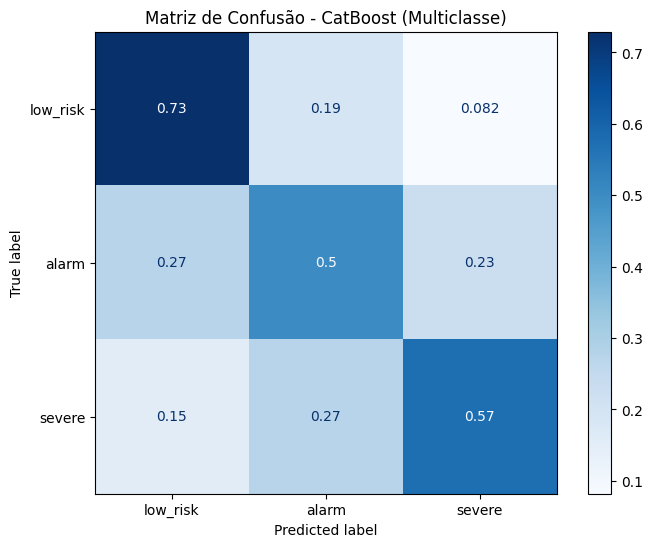

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_test, 
    display_labels=TARGET_NAMES,
    cmap='Blues',
    normalize='true',
    ax=ax
)
ax.set_title("Matriz de Confusão - CatBoost (Multiclasse)")
plt.show()